In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

In [5]:
from pathlib import Path
import pandas as pd

candidate_files = [
    Path("covid_19.csv"),
    Path("covid_19"),
    Path("data/covid_19.csv"),
    Path("data/covid_19"),
]
DATA_FILE = next((path for path in candidate_files if path.exists()), Path("covid_19.csv"))
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Place the supplied CSV next to this notebook or rename the file to one of: {', '.join(str(path) for path in candidate_files)}"
    )

raw = pd.read_csv(DATA_FILE)
print(f"{raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head(8)

368 rows × 7 columns


,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN
5,Sichuan,Mainland China,1/21/2020,2.0,1.0,NaN,NaN
6,Tianjin,Mainland China,1/21/2020,2.0,NaN,NaN,NaN
7,Ningxia,Mainland China,1/21/2020,NaN,1.0,NaN,NaN


In [6]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Province/State     304 non-null    str    
 1   Country            368 non-null    str    
 2   Date last updated  368 non-null    str    
 3   Confirmed          339 non-null    float64
 4   Suspected          88 non-null     float64
 5   Recovered          36 non-null     float64
 6   Deaths             24 non-null     float64
dtypes: float64(4), str(3)
memory usage: 20.3 KB


In [7]:
df = raw.copy()
count_cols = ["Confirmed", "Suspected", "Recovered", "Deaths"]

df["Province/State"] = df["Province/State"].fillna("National / unspecified")
df["Country"] = df["Country"].fillna("Unknown")
df["Date last updated"] = pd.to_datetime(df["Date last updated"], errors="coerce")
for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df = df.rename(columns={"Date last updated": "UpdatedAt", "Province/State": "Region"})
df["Reported total"] = df["Confirmed"] + df["Suspected"]
df["Outcome total"] = df["Recovered"] + df["Deaths"]
df["Outcome share recovered"] = np.where(
    df["Outcome total"] > 0, df["Recovered"] / df["Outcome total"], np.nan
)
df["Update day"] = df["UpdatedAt"].dt.strftime("%b %d")

print("Unparsed timestamps:", int(df["UpdatedAt"].isna().sum()))
df[["Region", "Country", "UpdatedAt", *count_cols, "Reported total"]].head()

Unparsed timestamps: 341


,Region,Country,UpdatedAt,Confirmed,Suspected,Recovered,Deaths,Reported total
0,Shanghai,Mainland China,2020-01-21,9.0,10.0,0.0,0.0,19.0
1,Yunnan,Mainland China,2020-01-21,1.0,0.0,0.0,0.0,1.0
2,Beijing,Mainland China,2020-01-21,10.0,0.0,0.0,0.0,10.0
3,Taiwan,Mainland China,2020-01-21,1.0,0.0,0.0,0.0,1.0
4,Jilin,Mainland China,2020-01-21,0.0,1.0,0.0,0.0,1.0


In [8]:
missing_before = raw.isna().sum().sort_values(ascending=False)
missing_before[missing_before.gt(0)].rename("Empty source cells").to_frame()

,Empty source cells
Deaths,344
Recovered,332
Suspected,280
Province/State,64
Confirmed,29


In [9]:
summary = pd.Series({
    "Locations in file": len(df),
    "Countries / territories": df["Country"].nunique(),
    "Distinct reporting timestamps": df["UpdatedAt"].nunique(),
    "First timestamp": df["UpdatedAt"].min(),
    "Last timestamp": df["UpdatedAt"].max(),
    "Rows with a parsed timestamp": df["UpdatedAt"].notna().sum(),
}, name="Value")
summary

Locations in file                                368
Countries / territories                           21
Distinct reporting timestamps                      1
First timestamp                  2020-01-21 00:00:00
Last timestamp                   2020-01-21 00:00:00
Rows with a parsed timestamp                      27
Name: Value, dtype: object

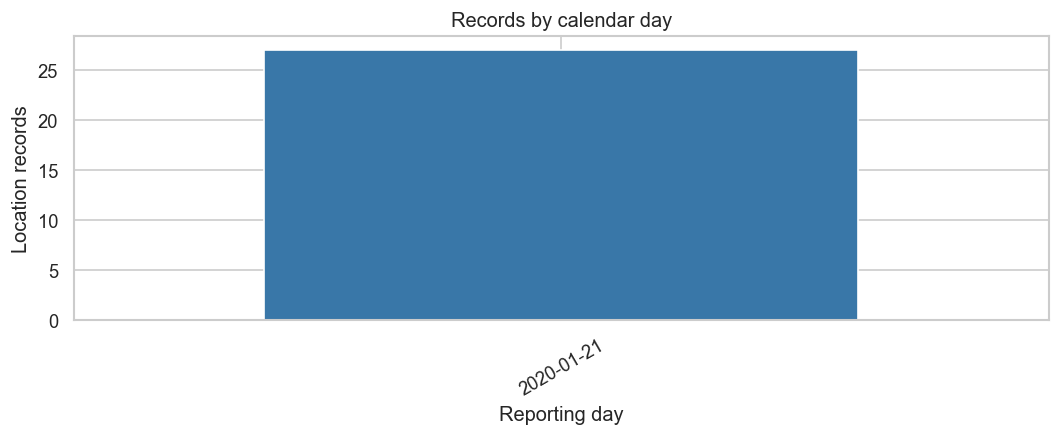

In [10]:
updates_per_day = df.groupby(df["UpdatedAt"].dt.date).size()
fig, ax = plt.subplots(figsize=(9, 3.8))
updates_per_day.plot(kind="bar", color="#3977a8", ax=ax, width=0.78)
ax.set(title="Records by calendar day", xlabel="Reporting day", ylabel="Location records")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

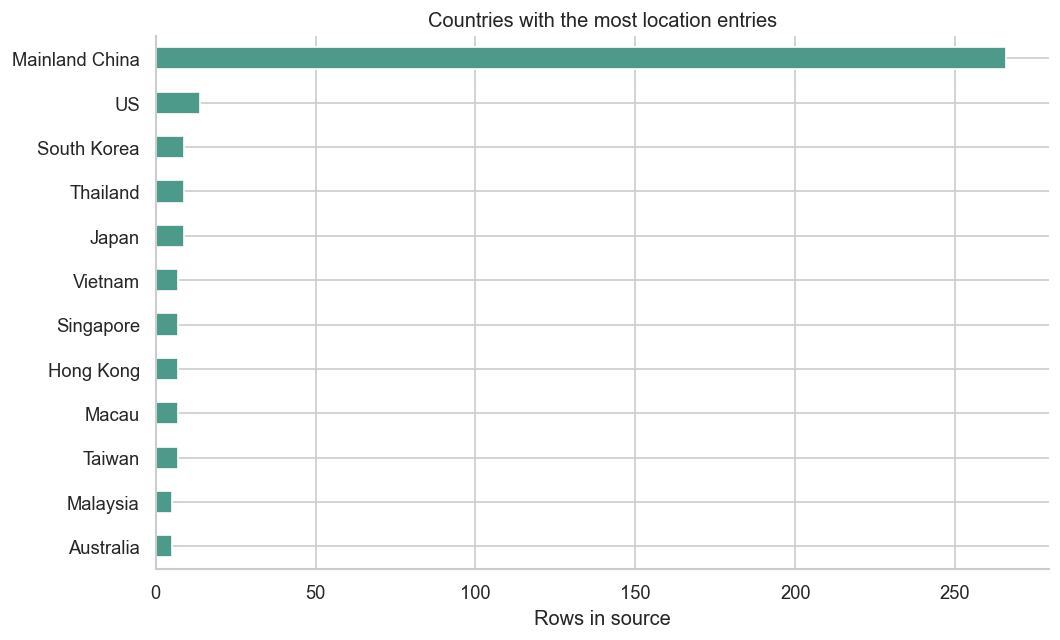

In [11]:
country_rows = df.groupby("Country").size().sort_values(ascending=False).head(12).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
country_rows.plot.barh(ax=ax, color="#4d9a8a")
ax.set(title="Countries with the most location entries", xlabel="Rows in source", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [12]:
latest_time = df["UpdatedAt"].max()
latest = df.loc[df["UpdatedAt"].eq(latest_time)].copy()
latest_country = latest.groupby("Country", as_index=False)[count_cols].sum()
latest_country["Reported total"] = latest_country["Confirmed"] + latest_country["Suspected"]
latest_country.sort_values("Reported total", ascending=False).head(10)


,Country,Confirmed,Suspected,Recovered,Deaths,Reported total
1,Mainland China,327.0,169.0,0.0,0.0,496.0
3,Thailand,2.0,0.0,0.0,0.0,2.0
0,Japan,1.0,0.0,0.0,0.0,1.0
2,South Korea,1.0,0.0,0.0,0.0,1.0
4,United States,1.0,0.0,0.0,0.0,1.0


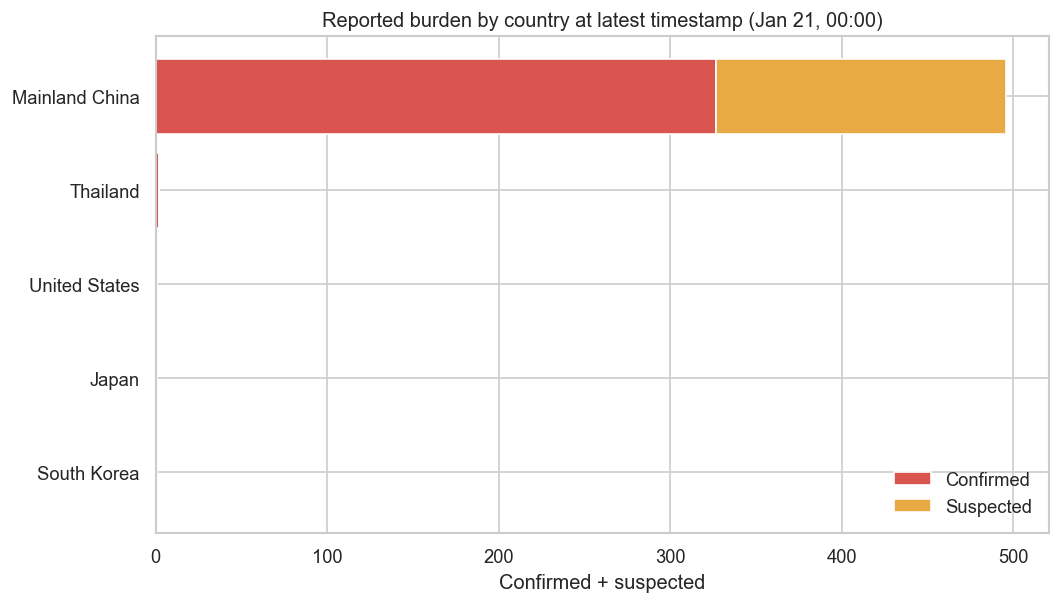

In [13]:
leaders = latest_country.nlargest(10, "Reported total").sort_values("Reported total")
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(leaders["Country"], leaders["Confirmed"], label="Confirmed", color="#d9534f")
ax.barh(leaders["Country"], leaders["Suspected"], left=leaders["Confirmed"], label="Suspected", color="#e8aa45")
ax.set(title=f"Reported burden by country at latest timestamp ({latest_time:%b %d, %H:%M})", xlabel="Confirmed + suspected", ylabel="")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


In [14]:
timeline = (df.dropna(subset=["UpdatedAt"])
            .groupby(["UpdatedAt", "Country"], as_index=False)[count_cols].sum())
timeline["Reported total"] = timeline["Confirmed"] + timeline["Suspected"]
top_trend_countries = (timeline.groupby("Country")["Reported total"]
                       .max().nlargest(6).index)
trend = timeline[timeline["Country"].isin(top_trend_countries)]


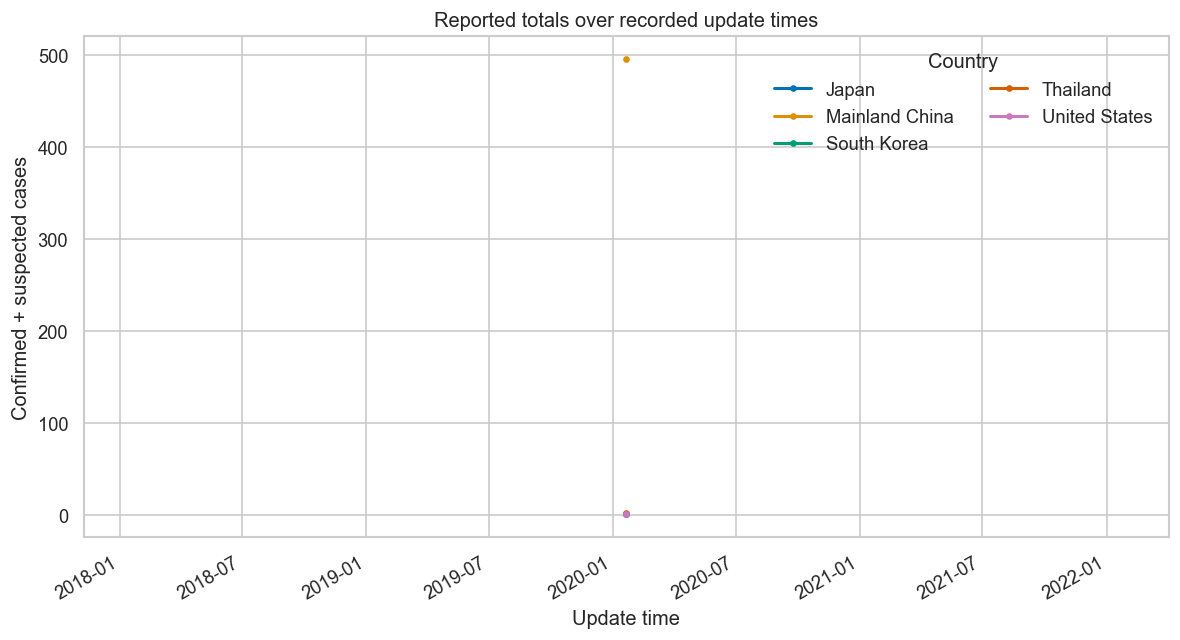

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for country, part in trend.groupby("Country"):
    part = part.sort_values("UpdatedAt")
    ax.plot(part["UpdatedAt"], part["Reported total"], marker="o", ms=3, lw=1.8, label=country)
ax.set(title="Reported totals over recorded update times", xlabel="Update time", ylabel="Confirmed + suspected cases")
ax.ticklabel_format(axis="y", style="plain")
ax.legend(title="Country", frameon=False, ncol=2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [16]:
china_rows = df[df["Country"].eq("Mainland China")].copy()
province_snapshot = (china_rows[china_rows["UpdatedAt"].eq(china_rows["UpdatedAt"].max())]
                    .groupby("Region", as_index=False)[count_cols].sum())
province_snapshot["Reported total"] = province_snapshot["Confirmed"] + province_snapshot["Suspected"]
province_snapshot.nlargest(8, "Reported total")


,Region,Confirmed,Suspected,Recovered,Deaths,Reported total
10,Hubei,270.0,11.0,0.0,0.0,281.0
9,Hong Kong,0.0,117.0,0.0,0.0,117.0
3,Guangdong,17.0,4.0,0.0,0.0,21.0
22,Zhejiang,5.0,16.0,0.0,0.0,21.0
17,Shanghai,9.0,10.0,0.0,0.0,19.0
1,Beijing,10.0,0.0,0.0,0.0,10.0
2,Chongqing,5.0,0.0,0.0,0.0,5.0
0,Anhui,0.0,3.0,0.0,0.0,3.0


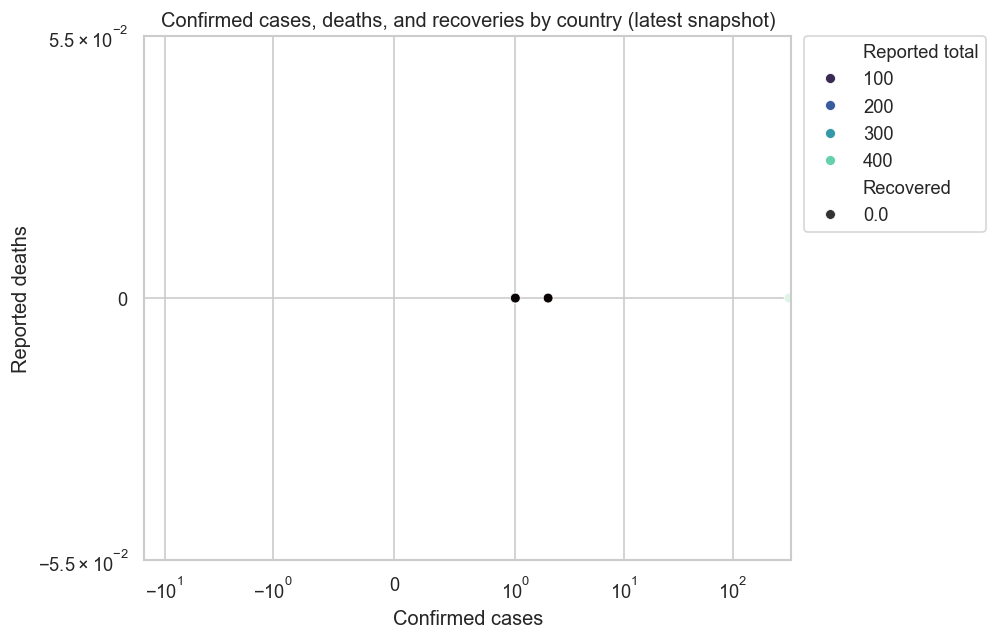

In [17]:
plot_df = latest_country.loc[latest_country["Confirmed"].gt(0)].copy()
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=plot_df, x="Confirmed", y="Deaths", size="Recovered", sizes=(35, 260),
                hue="Reported total", palette="mako", legend="brief", ax=ax)
ax.set(title="Confirmed cases, deaths, and recoveries by country (latest snapshot)",
       xlabel="Confirmed cases", ylabel="Reported deaths")
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


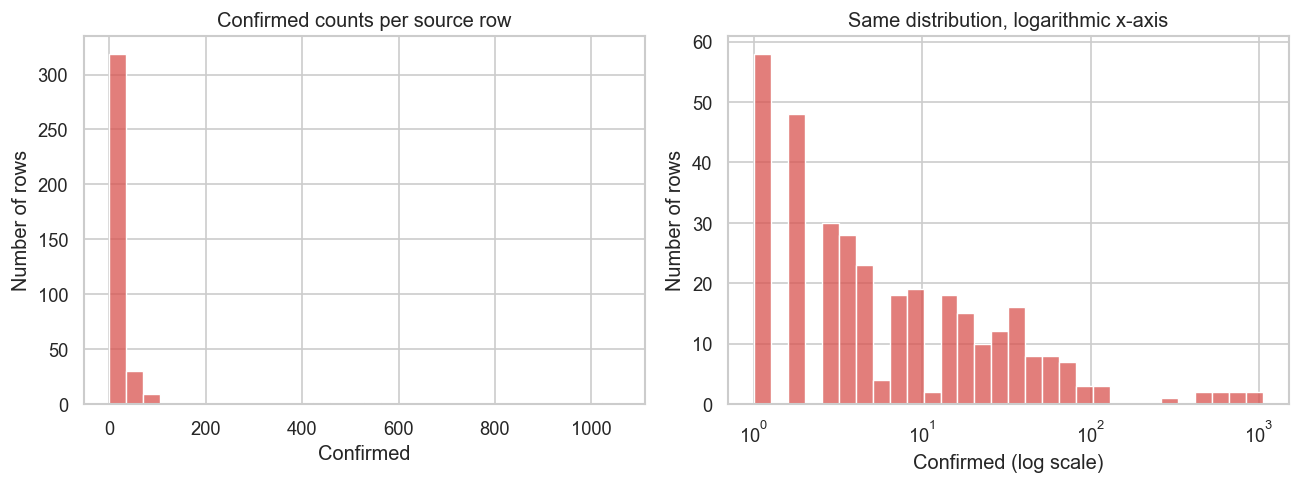

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.histplot(data=df, x="Confirmed", bins=30, color="#d9534f", ax=axes[0])
axes[0].set(title="Confirmed counts per source row", xlabel="Confirmed", ylabel="Number of rows")
sns.histplot(data=df, x="Confirmed", bins=30, color="#d9534f", ax=axes[1], log_scale=(True, False))
axes[1].set(title="Same distribution, logarithmic x-axis", xlabel="Confirmed (log scale)", ylabel="Number of rows")
plt.tight_layout()
plt.show()


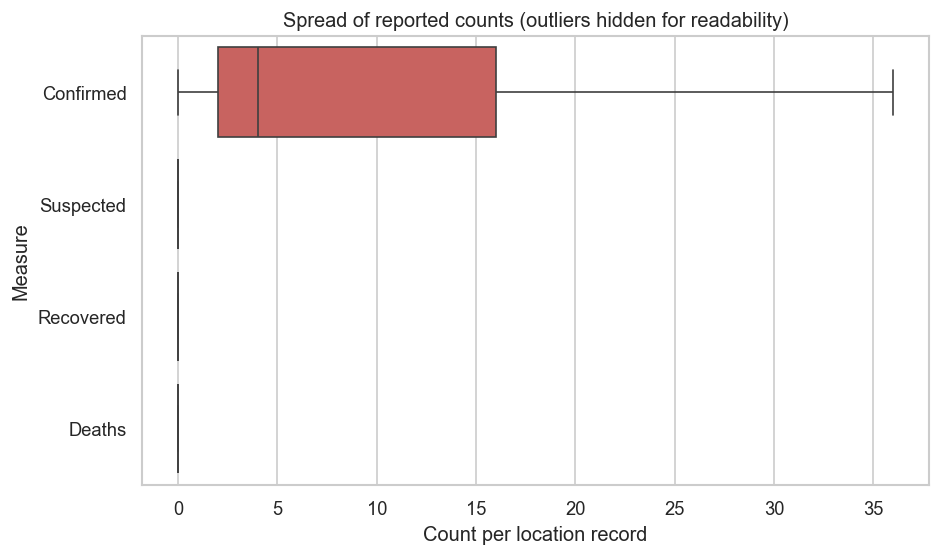

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.boxplot(data=df[count_cols], orient="h", showfliers=False, palette=["#d9534f", "#e8aa45", "#4d9a8a", "#596779"], ax=ax)
ax.set(title="Spread of reported counts (outliers hidden for readability)", xlabel="Count per location record", ylabel="Measure")
plt.tight_layout()
plt.show()


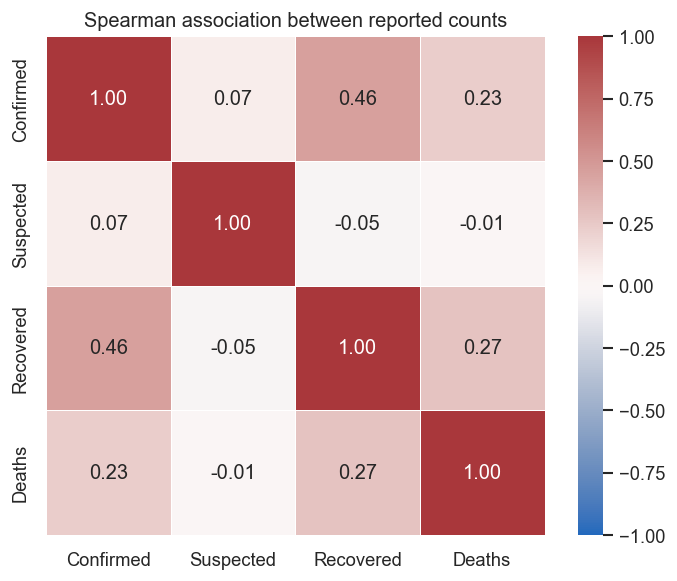

In [20]:
corr = df[count_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0,
            cmap="vlag", square=True, linewidths=.5, ax=ax)
ax.set_title("Spearman association between reported counts")
plt.tight_layout()
plt.show()


In [21]:
check = pd.Series({
    "Rows with reported deaths": int(df["Deaths"].gt(0).sum()),
    "Rows with reported recoveries": int(df["Recovered"].gt(0).sum()),
    "Rows with outcomes recorded": int(df["Outcome total"].gt(0).sum()),
    "Rows where outcomes exceed confirmed count": int((df["Outcome total"] > df["Confirmed"]).sum()),
}, name="Rows")
check.to_frame()


,Rows
Rows with reported deaths,24
Rows with reported recoveries,36
Rows with outcomes recorded,51
Rows where outcomes exceed confirmed count,0
